
# Hull-White One-Factor Model:Impled Volality

This notebook presents the theoretical framework and corresponding Python implementation of the Hull-White one-factor interest-rate model. Each section below provides LaTeX-formatted equations (denoted by `$...$` for inline and `$$...$$` for display) alongside explanations tied to the functions in the provided code.

---

## 1. Model Dynamics

The Hull–White model assumes that the short rate $r(t)$ evolves according to the stochastic differential equation (SDE):

$$
\mathrm{d}r(t) = \lambda\bigl(\theta(t) - r(t)\bigr)\,\mathrm{d}t + \eta\,\mathrm{d}W(t),
$$

where:

- $\lambda$ is the mean-reversion speed,
- $\theta(t)$ is the time-dependent level ensuring a fit to the initial term structure,
- $\eta$ is the volatility parameter,
- $W(t)$ is a standard Brownian motion.

In code, this is discretized in the function:

```python
R[:, i+1] = R[:, i] + \lambda(\theta(time[i]) - R[:, i])\,dt + \eta( W[:, i+1] - W[:, i] )
```

in **`GeneratePathsHWEuler`**, using an Euler–Maruyama scheme with step size $\Delta t = T / N$.

---

## 2. Calibration to the Initial Curve

We denote the initial zero-coupon bond curve by $P(0,T) \equiv P_{0T}(T)$. Its instantaneous forward rate is:

$$
f(0,T) = -\frac{\partial}{\partial T} \ln P(0,T).
$$

Numerically, we approximate this derivative via central differences:

```python
f0T(t) = -\frac{\ln(P0T(t+\delta)) - \ln(P0T(t-\delta))}{2\delta}
```

with $\delta = 10^{-4}$.

The function $\theta(t)$ ensuring the model matches the initial term structure is then given by:

$$
\theta(t) = \frac{1}{\lambda} \frac{\partial f(0,t)}{\partial t} + f(0,t) + \frac{\eta^2}{2\lambda^2}\bigl(1 - e^{-2\lambda t}\bigr).
$$

This is implemented in **`HW_theta(lambd,\,eta,\,P0T)`**.

---

## 3. Zero-Coupon Bond Pricing

Under the Hull–White model, the price at time $T_1$ of a zero-coupon bond maturing at $T_2$ given the short rate $r(T_1)=r_1$ has the affine form:

$$
P(T_1,T_2) = e^{A(T_1,T_2) + B(T_1,T_2)r_1},
$$

where

$$
B(T_1,T_2) = \frac{1}{\lambda}\bigl(e^{-\lambda (T_2 - T_1)} - 1\bigr),
$$

and

$$
A(T_1,T_2)
= \int_{0}^{T_2-T_1} \lambda\,\theta(T_2 - u)B(u)\,du
+ \frac{\eta^2}{4\lambda^3}\bigl(e^{-2\lambda (T_2-T_1)}(4e^{\lambda(T_2-T_1)}-1)-3\bigr) + \frac{\eta^2(T_2-T_1)}{2\lambda^2}.
$$

These are computed in **`HW_B`** and **`HW_A`**, and combined in **`HW_ZCB`**.

---

## 4. Monte Carlo Simulation of the Short Rate

To verify the analytic bond prices, we simulate $M$ paths of $r(t)$ over $[0,T]$:

1. Generate Gaussian increments:
   $$Z_{i+1} \sim \mathcal{N}(0,1),$$
2. Build the Wiener increments: $\Delta W_i = \sqrt{\Delta t}\,Z_{i}$.
3. Update rates via Euler:
   $$r_{i+1} = r_i + \lambda(\theta(t_i) - r_i)\,\Delta t + \eta\,\Delta W_i.$$

All of the above is in **`GeneratePathsHWEuler`**. The output `paths["R"]` and `paths["time"]` contain the simulated rates and time grid.

---

## 5. Discount Factors and Monte Carlo Bond Prices

From each path, we compute the money-market account:

$$M(t_i) = \exp\Bigl(\sum_{j=0}^{i-1} r_j\Delta t\Bigr),$$

and estimate:

$$\widehat P(0,T) = E\bigl[M(T)^{-1}\bigr].$$

This comparison is plotted against the analytical $P(0,T)$ in `mainCalculation()`.

---

## 6. Caplet/Floorlet and Black-76 Implied Volatility

A caplet on the forward rate between $T_1$ and $T_2$ can be priced via an option on a bond:

$$	ext{Caplet} = N(1 + (T_2 - T_1)K)\,\mathbb{E}^*\bigl[(P(T_1,T_2)-K^*)^+\bigr],$$

with $K^* = 1 + (T_2 - T_1)K$ under the forward measure. The function **`HW_CapletFloorletPrice`** transforms this into a bond option priced by **`HW_ZCB_CallPutPrice`**.

Finally, the Black–76 formula for an option on a forward rate is:

$$\mathrm{Black}(CP) =  
\Phi(d_1)F - \Phi(d_2)K e^{-r	au},
$$

with

$$d_{1,2} = \frac{\ln(F/K)\pm 0.5\sigma^2	au}{\sigma\sqrt{	au}},$$

and implied volatility found via **`ImpliedVolatilityBlack76`** using a root-finding on

$$ BS(CP;\sigma) - \text{price\_market} = 0. $$

---

**This completes the theoretical derivations and their mapping to the provided Python code.**
```



C:\Users\lenovo\AppData\Local\Temp\ipykernel_20264\2753347637.py:172: RuntimeWarning: divide by zero encountered in divide
  d1 = (np.log(S_0 / K) + (r + 0.5 * np.power(sigma, 2.0)) * tau) / (sigma * np.sqrt(tau))


Strike = 0.06147808720515882
Initial volatility = 0.10086333768744683
Final volatility = 0.1008671700107209
Strike = 0.07428602203956691
Initial volatility = 0.0944166636435747
Final volatility = 0.09442116084288076
Strike = 0.08709395687397499
Initial volatility = 0.08934344565771787
Final volatility = 0.08934571168144298
Strike = 0.09990189170838308
Initial volatility = 0.08521779480713086
Final volatility = 0.0852184762888301
Strike = 0.11270982654279116
Initial volatility = 0.0817798154783827
Final volatility = 0.08177995801370096
Strike = 0.12551776137719925
Initial volatility = 0.07886044182434666
Final volatility = 0.07886043867809372
Strike = 0.13832569621160734
Initial volatility = 0.0763430845456246
Final volatility = 0.07634349551436966
Strike = 0.1511336310460154
Initial volatility = 0.07414547159118785
Final volatility = 0.07414619981754361
Strike = 0.16394156588042352
Initial volatility = 0.07220554584918976
Final volatility = 0.0722076531389424
Strike = 0.176749500714831

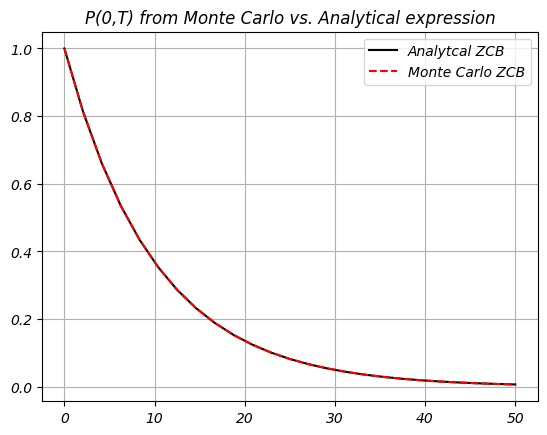

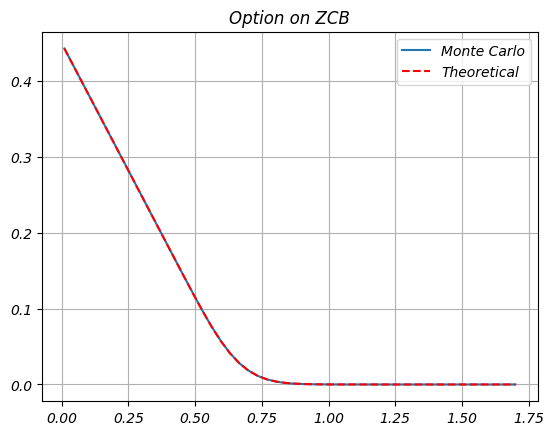

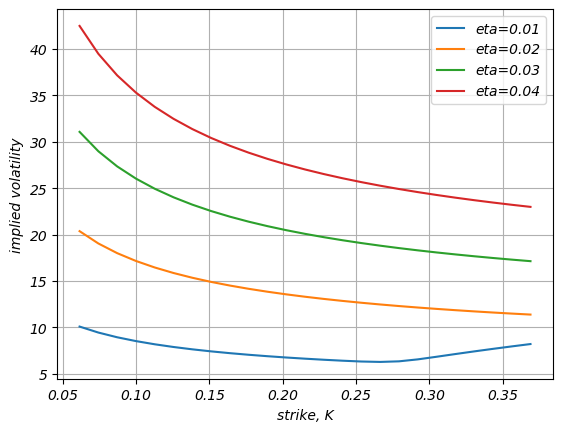

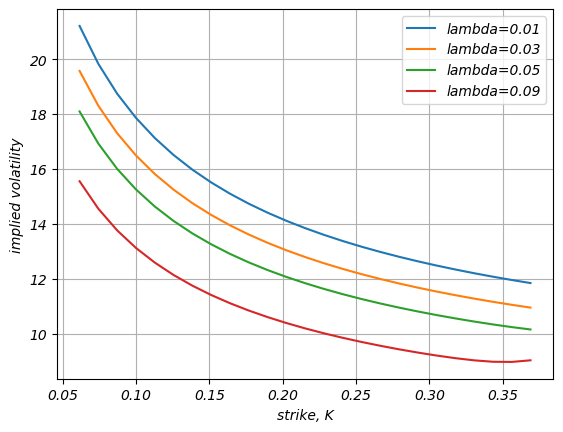

In [1]:
import numpy as np
import enum
import matplotlib.pyplot as plt
import scipy.stats as st
import scipy.integrate as integrate
import scipy.optimize as optimize
from scipy import interpolate


# This class defines puts and calls
class OptionType(enum.Enum):
    CALL = 1.0
    PUT = -1.0


def GeneratePathsHWEuler(NoOfPaths, NoOfSteps, T, P0T, lambd, eta):
    # time-step needed for differentiation
    dt = 0.0001
    f0T = lambda t: - (np.log(P0T(t + dt)) - np.log(P0T(t - dt))) / (2 * dt)

    # Initial interest rate is a forward rate at time t->0
    r0 = f0T(0.00001)
    theta = lambda t: 1.0 / lambd * (f0T(t + dt) - f0T(t - dt)) / (2.0 * dt) + f0T(t) + eta * eta / (
                2.0 * lambd * lambd) * (1.0 - np.exp(-2.0 * lambd * t))

    # theta = lambda t: 0.1 +t -t
    # print("changed theta")

    Z = np.random.normal(0.0, 1.0, [NoOfPaths, NoOfSteps])
    W = np.zeros([NoOfPaths, NoOfSteps + 1])
    R = np.zeros([NoOfPaths, NoOfSteps + 1])
    R[:, 0] = r0
    time = np.zeros([NoOfSteps + 1])

    dt = T / float(NoOfSteps)
    for i in range(0, NoOfSteps):
        # making sure that samples from normal have mean 0 and variance 1
        if NoOfPaths > 1:
            Z[:, i] = (Z[:, i] - np.mean(Z[:, i])) / np.std(Z[:, i])
        W[:, i + 1] = W[:, i] + np.power(dt, 0.5) * Z[:, i]
        R[:, i + 1] = R[:, i] + lambd * (theta(time[i]) - R[:, i]) * dt + eta * (W[:, i + 1] - W[:, i])
        time[i + 1] = time[i] + dt

    # Outputs
    paths = {"time": time, "R": R}
    return paths


def HW_theta(lambd, eta, P0T):
    dt = 0.0001
    f0T = lambda t: - (np.log(P0T(t + dt)) - np.log(P0T(t - dt))) / (2 * dt)
    theta = lambda t: 1.0 / lambd * (f0T(t + dt) - f0T(t - dt)) / (2.0 * dt) + f0T(t) + eta * eta / (
                2.0 * lambd * lambd) * (1.0 - np.exp(-2.0 * lambd * t))
    # print("CHANGED THETA")
    return theta  # lambda t: 0.1+t-t


def HW_A(lambd, eta, P0T, T1, T2):
    tau = T2 - T1
    zGrid = np.linspace(0.0, tau, 250)
    B_r = lambda tau: 1.0 / lambd * (np.exp(-lambd * tau) - 1.0)
    theta = HW_theta(lambd, eta, P0T)
    temp1 = lambd * integrate.trapz(theta(T2 - zGrid) * B_r(zGrid), zGrid)

    temp2 = eta * eta / (4.0 * np.power(lambd, 3.0)) * (
                np.exp(-2.0 * lambd * tau) * (4 * np.exp(lambd * tau) - 1.0) - 3.0) + eta * eta * tau / (
                        2.0 * lambd * lambd)

    return temp1 + temp2


def HW_B(lambd, eta, T1, T2):
    return 1.0 / lambd * (np.exp(-lambd * (T2 - T1)) - 1.0)


def HW_ZCB(lambd, eta, P0T, T1, T2, rT1):
    B_r = HW_B(lambd, eta, T1, T2)
    A_r = HW_A(lambd, eta, P0T, T1, T2)
    return np.exp(A_r + B_r * rT1)


def HWMean_r(P0T, lambd, eta, T):
    # time-step needed for differentiation
    dt = 0.0001
    f0T = lambda t: - (np.log(P0T(t + dt)) - np.log(P0T(t - dt))) / (2.0 * dt)
    # Initial interest rate is a forward rate at time t->0
    r0 = f0T(0.00001)
    theta = HW_theta(lambd, eta, P0T)
    zGrid = np.linspace(0.0, T, 2500)
    temp = lambda z: theta(z) * np.exp(-lambd * (T - z))
    r_mean = r0 * np.exp(-lambd * T) + lambd * integrate.trapz(temp(zGrid), zGrid)
    return r_mean


def HW_r_0(P0T, lambd, eta):
    # time-step needed for differentiation
    dt = 0.0001
    f0T = lambda t: - (np.log(P0T(t + dt)) - np.log(P0T(t - dt))) / (2 * dt)
    # Initial interest rate is a forward rate at time t->0
    r0 = f0T(0.00001)
    return r0


def HW_Mu_FrwdMeasure(P0T, lambd, eta, T):
    # time-step needed for differentiation
    dt = 0.0001
    f0T = lambda t: - (np.log(P0T(t + dt)) - np.log(P0T(t - dt))) / (2 * dt)
    # Initial interest rate is a forward rate at time t->0
    r0 = f0T(0.00001)
    theta = HW_theta(lambd, eta, P0T)
    zGrid = np.linspace(0.0, T, 500)

    theta_hat = lambda t, T: theta(t) + eta * eta / lambd * 1.0 / lambd * (np.exp(-lambd * (T - t)) - 1.0)

    temp = lambda z: theta_hat(z, T) * np.exp(-lambd * (T - z))

    r_mean = r0 * np.exp(-lambd * T) + lambd * integrate.trapz(temp(zGrid), zGrid)

    return r_mean


def HWVar_r(lambd, eta, T):
    return eta * eta / (2.0 * lambd) * (1.0 - np.exp(-2.0 * lambd * T))


def HWDensity(P0T, lambd, eta, T):
    r_mean = HWMean_r(P0T, lambd, eta, T)
    r_var = HWVar_r(lambd, eta, T)
    return lambda x: st.norm.pdf(x, r_mean, np.sqrt(r_var))


def HW_CapletFloorletPrice(CP, N, K, lambd, eta, P0T, T1, T2):
    if CP == OptionType.CALL:
        N_new = N * (1.0 + (T2 - T1) * K)
        K_new = 1.0 + (T2 - T1) * K
        caplet = N_new * HW_ZCB_CallPutPrice(OptionType.PUT, 1.0 / K_new, lambd, eta, P0T, T1, T2)
        value = caplet
    elif CP == OptionType.PUT:
        N_new = N * (1.0 + (T2 - T1) * K)
        K_new = 1.0 + (T2 - T1) * K
        floorlet = N_new * HW_ZCB_CallPutPrice(OptionType.CALL, 1.0 / K_new, lambd, eta, P0T, T1, T2)
        value = floorlet
    return value


def HW_ZCB_CallPutPrice(CP, K, lambd, eta, P0T, T1, T2):
    B_r = HW_B(lambd, eta, T1, T2)
    A_r = HW_A(lambd, eta, P0T, T1, T2)

    mu_r = HW_Mu_FrwdMeasure(P0T, lambd, eta, T1)
    v_r = np.sqrt(HWVar_r(lambd, eta, T1))

    K_hat = K * np.exp(-A_r)
    a = (np.log(K_hat) - B_r * mu_r) / (B_r * v_r)

    d1 = a - B_r * v_r
    d2 = d1 + B_r * v_r

    term1 = np.exp(0.5 * B_r * B_r * v_r * v_r + B_r * mu_r) * st.norm.cdf(d1) - K_hat * st.norm.cdf(d2)
    value = P0T(T1) * np.exp(A_r) * term1

    if CP == OptionType.CALL:

        return value
    elif CP == OptionType.PUT:
        return value - P0T(T2) + K * P0T(T1)


def BS_Call_Put_Option_Price(CP, S_0, K, sigma, tau, r):
    if K is list:
        K = np.array(K).reshape([len(K), 1])
    d1 = (np.log(S_0 / K) + (r + 0.5 * np.power(sigma, 2.0)) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    if CP == OptionType.CALL:
        value = st.norm.cdf(d1) * S_0 - st.norm.cdf(d2) * K * np.exp(-r * tau)
    elif CP == OptionType.PUT:
        value = st.norm.cdf(-d2) * K * np.exp(-r * tau) - st.norm.cdf(-d1) * S_0
    return value


def ImpliedVolatilityBlack76(CP, marketPrice, K, T, S_0):
    # To determine initial volatility we interpolate define a grid for sigma
    # and interpolate on the inverse
    sigmaGrid = np.linspace(0.0, 5.0, 5000)
    optPriceGrid = BS_Call_Put_Option_Price(CP, S_0, K, sigmaGrid, T, 0.0)
    sigmaInitial = np.interp(marketPrice, optPriceGrid, sigmaGrid)
    print("Strike = {0}".format(K))
    print("Initial volatility = {0}".format(sigmaInitial))

    # Use determined input for the local-search (final tuning)
    func = lambda sigma: np.power(BS_Call_Put_Option_Price(CP, S_0, K, sigma, T, 0.0) - marketPrice, 1.0)
    impliedVol = optimize.newton(func, sigmaInitial, tol=1e-15)
    print("Final volatility = {0}".format(impliedVol))
    if impliedVol > 2.0:
        impliedVol = 0.0
    return impliedVol


def mainCalculation():
    CP = OptionType.CALL
    NoOfPaths = 20000
    NoOfSteps = 1000

    lambd = 0.02
    eta = 0.02

    P0T = lambda T: np.exp(-0.1 * T)  # np.exp(-0.03*T*T-0.1*T)
    r0 = HW_r_0(P0T, lambd, eta)
    r0 = HW_r_0(P0T, lambd, eta)

    N = 25
    T_end = 50
    Tgrid = np.linspace(0, T_end, N)
    Exact = np.zeros([N, 1])
    Proxy = np.zeros([N, 1])
    for i, Ti in enumerate(Tgrid):
        Proxy[i] = HW_ZCB(lambd, eta, P0T, 0.0, Ti, r0)
        Exact[i] = P0T(Ti)
    plt.figure(1)
    plt.grid()
    plt.plot(Tgrid, Exact, '-k')
    plt.plot(Tgrid, Proxy, '--r')
    plt.legend(["Analytcal ZCB", "Monte Carlo ZCB"])
    plt.title('P(0,T) from Monte Carlo vs. Analytical expression')

    # in the experiment we campare mc resylt with
    T1 = 4
    T2 = 8
    paths = GeneratePathsHWEuler(NoOfPaths, NoOfSteps, T1, P0T, lambd, eta)
    r = paths["R"]
    timeGrid = paths["time"]
    dt = timeGrid[1] - timeGrid[0]
    #  # Here we compare the price of an option on a ZCB from Monte Carlo and Analytical expression
    M_t = np.zeros([NoOfPaths, NoOfSteps])
    for i in range(0, NoOfPaths):
        M_t[i, :] = np.exp(np.cumsum(r[i, :-1]) * dt)

    KVec = np.linspace(0.01, 1.7, 50)
    Price_MC_V = np.zeros([len(KVec), 1])
    Price_Th_V = np.zeros([len(KVec), 1])
    P_T1_T2 = HW_ZCB(lambd, eta, P0T, T1, T2, r[:, -1])
    for i, K in enumerate(KVec):
        if CP == OptionType.CALL:
            Price_MC_V[i] = np.mean(1.0 / M_t[:, -1] * np.maximum(P_T1_T2 - K, 0.0))
        elif CP == OptionType.PUT:
            Price_MC_V[i] = np.mean(1.0 / M_t[:, -1] * np.maximum(K - P_T1_T2, 0.0))
        Price_Th_V[i] = HW_ZCB_CallPutPrice(CP, K, lambd, eta, P0T, T1, T2)

    plt.figure(2)
    plt.grid()
    plt.plot(KVec, Price_MC_V)
    plt.plot(KVec, Price_Th_V, '--r')
    plt.legend(['Monte Carlo', 'Theoretical'])
    plt.title('Option on ZCB')

    # Effect of the HW model parameters on Implied Volatilities
    # define a forward rate between T1 and T2

    frwd = 1.0 / (T2 - T1) * (P0T(T1) / P0T(T2) - 1.0)
    K = np.linspace(frwd / 2.0, 3.0 * frwd, 25)

    # Effect of eta
    # Effect of eta
    plt.figure(3)
    plt.grid()
    plt.xlabel('strike, K')
    plt.ylabel('implied volatility')
    etaV = [0.01, 0.02, 0.03, 0.04]
    legend = []
    Notional = 1.0
    for etaTemp in etaV:
        optPrice = HW_CapletFloorletPrice(CP, Notional, K, lambd, etaTemp, P0T, T1, T2)
        # Implied volatilities
        IV = np.zeros([len(K), 1])
        for idx in range(0, len(K)):
            valFrwd = optPrice[idx] / P0T(T2) / (T2 - T1)
            IV[idx] = ImpliedVolatilityBlack76(CP, valFrwd, K[idx], T2, frwd)
        plt.plot(K, IV * 100.0)
        # plt.plot(K,optPrice)
        legend.append('eta={0}'.format(etaTemp))
    plt.legend(legend)

    # Effect of lambda
    plt.figure(4)
    plt.grid()
    plt.xlabel('strike, K')
    plt.ylabel('implied volatility')
    lambdaV = [0.01, 0.03, 0.05, 0.09]
    legend = []
    Notional = 1.0
    for lambdTemp in lambdaV:
        optPrice = HW_CapletFloorletPrice(CP, Notional, K, lambdTemp, eta, P0T, T1, T2)
        # Implied volatilities
        IV = np.zeros([len(K), 1])
        for idx in range(0, len(K)):
            valFrwd = optPrice[idx] / P0T(T2) / (T2 - T1)
            IV[idx] = ImpliedVolatilityBlack76(CP, valFrwd, K[idx], T2, frwd)
        # plt.plot(K,optPrice)
        plt.plot(K, IV * 100.0)
        legend.append('lambda={0}'.format(lambdTemp))
    plt.legend(legend)

    print('frwd={0}'.format(frwd * P0T(T2)))


mainCalculation()

